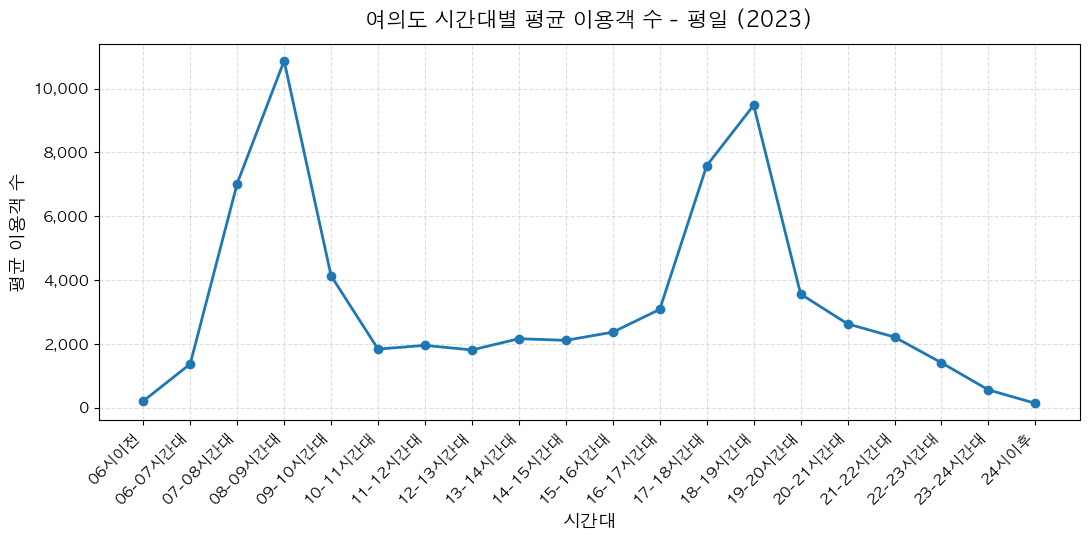

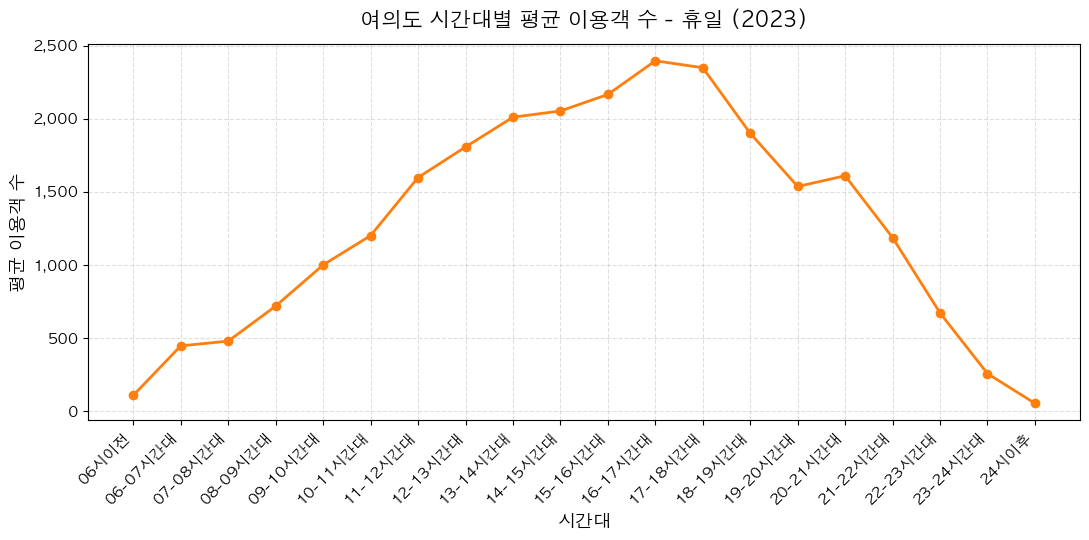

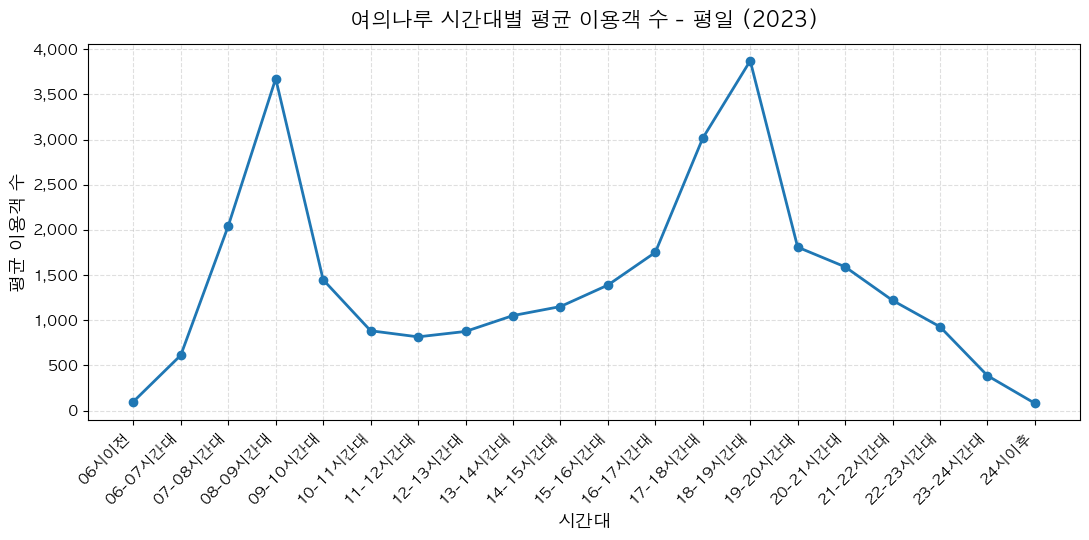

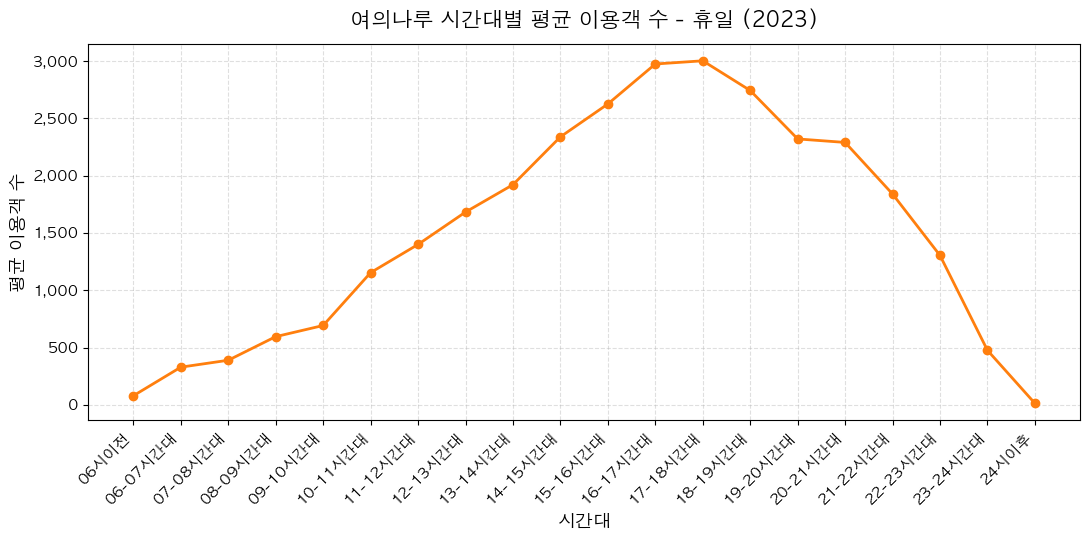

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import platform
import re
from pathlib import Path

if platform.system() == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:                               # Windows / Linux
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

file_name = "서울교통공사_역별 시간대별 승하차인원(23.1~23.12) (1).csv"
data_candidates = [Path("./Data/Metro") / file_name, Path("../Data/Metro") / file_name]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"데이터 파일을 찾을 수 없습니다: {file_name}")

subway_df = pd.read_csv(data_path, encoding="cp949")

date_column_candidates = [
    column for column in subway_df.columns
    if any(token in column for token in ("일자", "날짜")) or "date" in column.lower()
]
if not date_column_candidates:
    raise ValueError("날짜 컬럼을 찾지 못했습니다.")

date_column = date_column_candidates[0]
station_column = "역명" if "역명" in subway_df.columns else next(
    (column for column in subway_df.columns if "역명" in column), None
)
if station_column is None:
    raise ValueError("역명 컬럼을 찾지 못했습니다.")

subway_df[date_column] = pd.to_datetime(subway_df[date_column], errors="coerce")
subway_2023 = subway_df[subway_df[date_column].dt.year == 2023].copy()


def time_sort_key(column_name):
    if match := re.fullmatch(r"(\d{1,2})시이전", column_name):
        return int(match.group(1)) - 0.5
    if match := re.fullmatch(r"(\d{1,2})-(\d{1,2})시간대", column_name):
        return int(match.group(1))
    if match := re.fullmatch(r"(\d{1,2})시이후", column_name):
        return int(match.group(1)) + 0.5
    return None


time_slots = [column for column in subway_2023.columns if time_sort_key(column) is not None]
time_slots = sorted(time_slots, key=time_sort_key)
if not time_slots:
    raise ValueError("시간대 컬럼을 찾지 못했습니다.")

subway_2023[time_slots] = (
    subway_2023[time_slots]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

requested_stations = ["국회의사당", "샛강", "여의도", "여의나루"]
available_stations = set(subway_2023[station_column].dropna().unique())
target_stations = [station for station in requested_stations if station in available_stations]
if not target_stations:
    raise ValueError("2023년 데이터에서 여의도권 역을 찾지 못했습니다.")

holiday_dates = pd.to_datetime([
    "2023-01-01", "2023-01-21", "2023-01-22", "2023-01-23", "2023-01-24",
    "2023-03-01", "2023-05-05", "2023-05-27", "2023-05-29", "2023-06-06",
    "2023-08-15", "2023-09-28", "2023-09-29", "2023-09-30", "2023-10-02",
    "2023-10-03", "2023-10-09", "2023-12-25"
])

station_daily_usage = (
    subway_2023[subway_2023[station_column].isin(target_stations)]
    .groupby([date_column, station_column], as_index=False)[time_slots]
    .sum()
)
station_daily_usage["일자구분"] = np.where(
    station_daily_usage[date_column].dt.weekday.ge(5)
    | station_daily_usage[date_column].isin(holiday_dates),
    "휴일",
    "평일"
)

station_hourly_avg = (
    station_daily_usage
    .groupby([station_column, "일자구분"])[time_slots]
    .mean()
)

for station in target_stations:
    for day_type, line_color in [("평일", "#1f77b4"), ("휴일", "#ff7f0e")]:
        if (station, day_type) not in station_hourly_avg.index:
            continue

        station_usage = station_hourly_avg.loc[(station, day_type)]
        fig, ax = plt.subplots(figsize=(11, 5.5))
        x_positions = range(len(time_slots))

        ax.plot(
            x_positions,
            station_usage.values,
            marker="o",
            linewidth=2,
            markersize=6,
            color=line_color
        )
        ax.set_xticks(list(x_positions))
        ax.set_xticklabels(time_slots, rotation=45, ha="right")
        ax.set_title(f"{station} 시간대별 평균 이용객 수 - {day_type} (2023)", fontsize=15, pad=12)
        ax.set_xlabel("시간대", fontsize=13)
        ax.set_ylabel("평균 이용객 수", fontsize=13)
        ax.tick_params(axis="both", labelsize=11)
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
        ax.grid(True, linestyle="--", alpha=0.4)

        fig.tight_layout()
        plt.show()
        plt.close(fig)
